In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from tqdm import tqdm
import random
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout, Activation
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#from keras.models import Sequential
#from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout, Activation
#from keras import optimizers
#from keras_preprocessing.image import ImageDataGenerator

from keras.models import load_model

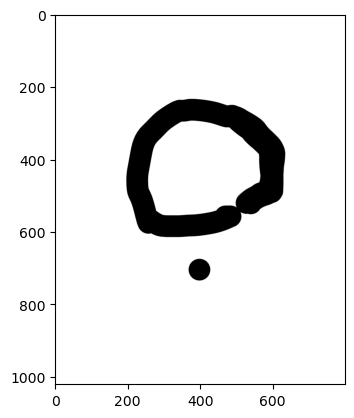

In [3]:
img = cv.imread("C:/Users/OWNER/Machine Learning/FYP/img/img017_1.png")
plt.imshow(img)

In [6]:
df = pd.read_csv(r'C:/Users/OWNER/Machine Learning/FYP/yoruba character.csv')
df.head()

,image,label
0,img/img001_1.png,A
1,img/img001_2.png,A
2,img/img001_3.png,A
3,img/img001_4.png,A
4,img/img001_5.png,A


In [7]:
df.describe()

,image,label
count,5000,5000
unique,5000,50
top,img/img001_1.png,A
freq,1,100


In [8]:
classes = df['label'].unique()
print(f'\nThe Classes:\n {classes} ')


The Classes:
 ['A' 'B' 'D' 'E' 'Ẹ' 'F' 'G' 'GB' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'Ọ' 'P'
 'R' 'S' 'Ṣ' 'T' 'U' 'W' 'Y' 'a' 'b' 'd' 'e' 'ẹ' 'f' 'g' 'gb' 'h' 'i' 'j'
 'k' 'l' 'm' 'n' 'o' 'ọ' 'p' 'r' 's' 'ṣ' 't' 'u' 'w' 'y'] 


In [5]:
# Define the data path
DATADIR = "C:/Users/OWNER/Machine Learning/FYP/"         

# Read the csv file
dataset = pd.read_csv(DATADIR + '/yoruba character.csv')
# Get a 500 random values/rows
rand = random.sample(range(len(dataset)), 500)
# Make the random 500 as a validation data
validation_set = pd.DataFrame(dataset.iloc[rand, :].values, columns=['image', 'label'])
# Drop the 500 from the orignal data set
dataset.drop(rand, inplace=True)
# Get a 5 random rows/values from the validation set
rand = random.sample(range(len(validation_set)), 5)
# from the 5 random Create the test set 
test_set = pd.DataFrame(validation_set.iloc[rand, :].values, columns=['image', 'label'])
# Drop the 5 from the validation set
validation_set.drop(rand, inplace=True)
# Show the validation set as a example
validation_set

,image,label
0,img/img040_35.png,n
1,img/img004_74.png,E
2,img/img025_79.png,Y
3,img/img040_71.png,n
4,img/img045_64.png,s
...,...,...
495,img/img046_63.png,ṣ
496,img/img040_90.png,n
497,img/img013_21.png,L
498,img/img010_69.png,I


In [6]:
train_data_generator = ImageDataGenerator(rescale=1/255, shear_range=0.2, zoom_range=0.2)
data_generator = ImageDataGenerator(rescale=1/255)
training_data_frame = train_data_generator.flow_from_dataframe(dataframe=dataset, directory=DATADIR, x_col='image', y_col='label', 
                                                               target_size=(64, 64), class_mode='categorical')
validation_data_frame = data_generator.flow_from_dataframe(dataframe=validation_set, directory=DATADIR, x_col='image', y_col='label', 
                                                           target_size=(64, 64), class_mode='categorical')
test_data_frame = data_generator.flow_from_dataframe(dataframe=test_set, directory=DATADIR, x_col='image', y_col='label', 
                                                     target_size=(64, 64), class_mode='categorical', shuffle=False)

Found 4500 validated image filenames belonging to 50 classes.
Found 495 validated image filenames belonging to 50 classes.
Found 5 validated image filenames belonging to 4 classes.


In [7]:
# Define the model
model = Sequential()

# Add first Convolutional Layer
model.add(Conv2D(32, (3, 3), padding='same',
                 input_shape=(64,64,3)))
# Add a relu Activation 
model.add(Activation('relu'))
# Add a second Convolutional Layer
model.add(Conv2D(32, (3, 3)))
# Add a relu Activation 
model.add(Activation('relu'))
# Add a Max pooling layer
model.add(MaxPool2D(pool_size=(2, 2)))
# Add a Dropout layer
model.add(Dropout(0.25))

# Add third Convolutional Layer
model.add(Conv2D(64, (3, 3), padding='same'))
# Add a relu Activation 
model.add(Activation('relu'))
# Add Fourth Convolutional Layer
model.add(Conv2D(64, (3, 3)))
# Add a relu Activation 
model.add(Activation('relu'))
# Add a Max pooling layer
model.add(MaxPool2D(pool_size=(2, 2)))
# Add a Dropout Layer
model.add(Dropout(0.25))

# Add Fifth Convolutional Layer
model.add(Conv2D(64, (3, 3), padding='same'))
# Add a Activation Layer
model.add(Activation('relu'))
# Add a sixth Convolutional Layer
model.add(Conv2D(64, (3, 3)))
# Add a Activation Layer
model.add(Activation('relu'))
# Add a Max Pooling Layer
model.add(MaxPool2D(pool_size=(2, 2)))
# Add a Dropout Layer
model.add(Dropout(0.25))

# Add a Flatten Layer
model.add(Flatten())
# Add a Dense layer Layer
model.add(Dense(512))
# Add a Activation Layer
model.add(Activation('relu'))
# Add a Dropout Layer
model.add(Dropout(0.5))
# Add the Output Dense Layer
model.add(Dense(50, activation='softmax'))

# Compile the model
model.compile(optimizers.RMSprop(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

C:\Users\OWNER\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Train the model for 50 epochs
history = model.fit(training_data_frame, validation_data=validation_data_frame, epochs=50)

C:\Users\OWNER\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.0242 - loss: 3.9185 - val_accuracy: 0.0222 - val_loss: 3.9120
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 130s 925ms/step - accuracy: 0.0205 - loss: 3.9117 - val_accuracy: 0.0384 - val_loss: 3.8999
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.0534 - loss: 3.8478 - val_accuracy: 0.1576 - val_loss: 3.3749
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 139s 984ms/step - accuracy: 0.1276 - loss: 3.4490 - val_accuracy: 0.2182 - val_loss: 2.9632
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 139s 987ms/step - accuracy: 0.1817 - loss: 3.1351 - val_accuracy: 0.3374 - val_loss: 2.6136
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.2211 - loss: 2.9656 - val_accuracy: 0.3960 - val_loss: 2.3997
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 134s 951ms/step - accuracy: 0.2843 - loss: 2.6937 - val_accuracy: 0.4687 - val_loss: 2.1733
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 137s 973ms/step - accuracy: 0.3151 - loss: 2.

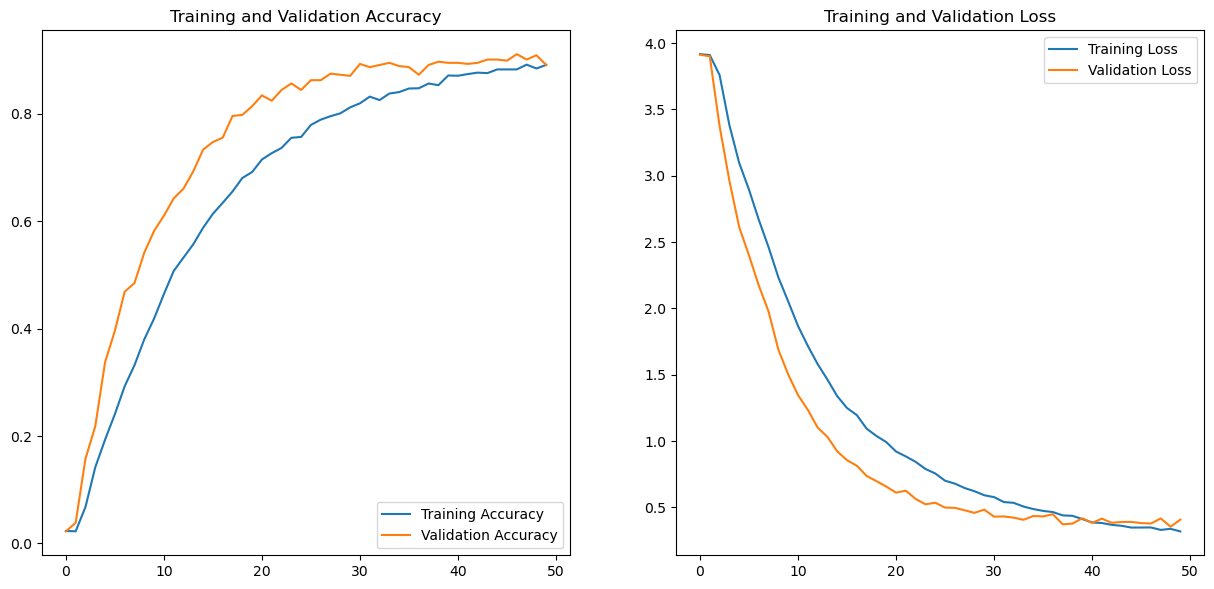

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(50)

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [10]:
# Save the model as model.h5
model.save('mymodel.h5')
# Load the model
model = load_model('mymodel.h5')

Prediction Dict:  {'A': 0, 'B': 1, 'D': 2, 'E': 3, 'F': 4, 'G': 5, 'GB': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'R': 16, 'S': 17, 'T': 18, 'U': 19, 'W': 20, 'Y': 21, 'a': 22, 'b': 23, 'd': 24, 'e': 25, 'f': 26, 'g': 27, 'gb': 28, 'h': 29, 'i': 30, 'j': 31, 'k': 32, 'l': 33, 'm': 34, 'n': 35, 'o': 36, 'p': 37, 'r': 38, 's': 39, 't': 40, 'u': 41, 'w': 42, 'y': 43, 'Ṣ': 44, 'ṣ': 45, 'Ẹ': 46, 'ẹ': 47, 'Ọ': 48, 'ọ': 49}
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
Max index:  [38, 11, 11, 34, 43]


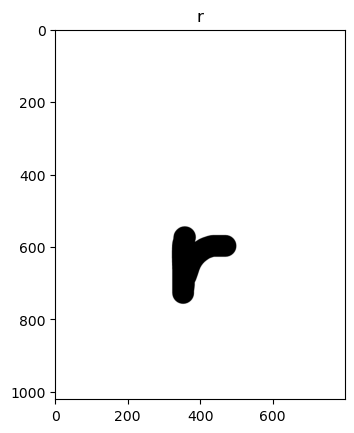

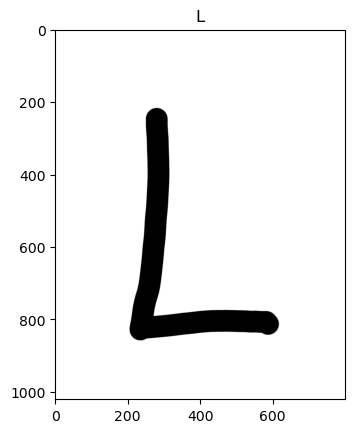

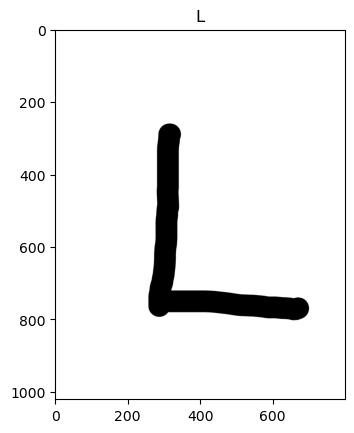

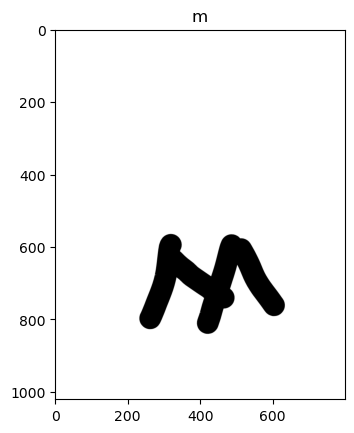

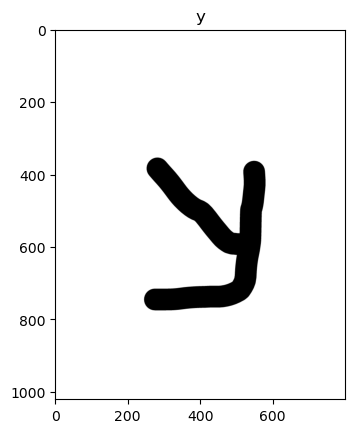

In [11]:
# Print the class indices 
print("Prediction Dict: ", training_data_frame.class_indices)
# Predict on the test data 
pred = model.predict(test_data_frame)
# Create a class/labels dictionary
classDict = {0:'A', 1:'B', 2:'D', 3:'E', 4: 'F', 5:'G', 6:'GB', 7:'H', 8:'I', 9:'J', 10:'K', 
                 11:'L', 12:'M', 13:'N', 14:'O', 15:'P', 16:'R', 17: 'S', 18: 'T', 19: 'U', 20: 'W', 
                 21: 'Y', 22: 'a', 23: 'b', 24: 'd', 25:'e', 26:'f', 27:'g', 28:'gb', 29:'h', 30:'i', 
                 31: 'j', 32: 'k', 33: 'l', 34: 'm', 35: 'n', 36: 'o', 37: 'p', 38: 'r', 39: 's', 40: 't', 
                 41: 'u', 42: 'w', 43:'y', 44:'Ṣ', 45:'ṣ', 46:'Ẹ', 47:'ẹ', 48:'Ọ', 49:'ọ'}

# Make a data frame that contains the probability for each class
outputDf = pd.DataFrame(pred)
# Get the index of the max probability from the output Data frame
maxIndex = list(outputDf.idxmax(axis=1))
# Print the max index
print("Max index: ", maxIndex)
# Make a loop in range the length of the test data (5)
for i in range(len(test_set)):
    # Read the image 
    image = cv.imread(DATADIR + '/' + test_set.at[i, 'image'])
    # The title of the plot which is the predicted label
    plt.title(classDict.get(maxIndex[i], "error"))
    # Show the actual image
    plt.imshow(image)
    plt.show()

In [4]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os

In [5]:
#load model
model = load_model('mymodel.h5')
#define image path
image_path = 'C:/Users/OWNER/Machine Learning/FYP/img/img001_31.png'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
Predicted Class: 31


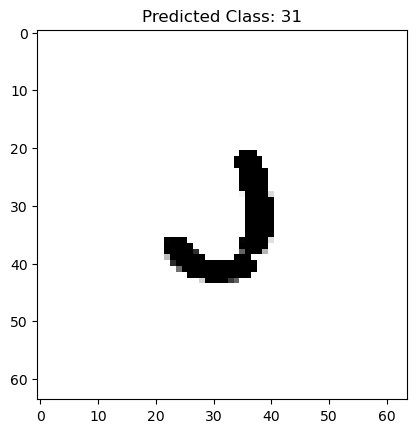

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('C:/Users/OWNER/Machine Learning/FYP/img/img036_2.png')

# Process the image
img = cv2.resize(img, (64, 64))
img = img.astype('float32') / 255.0

# Expand the dimensions of the image
img = np.expand_dims(img, axis=0)

# Predict the class
prediction = model.predict(img)
predicted_class = np.argmax(prediction)

# Print the predicted class
print(f'Predicted Class: {predicted_class}')

# Show the image
plt.imshow(img[0])  # Assuming img is a batch with a single image
plt.title(f'Predicted Class: {predicted_class}')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted Label: Ṣ with probability: 0.95


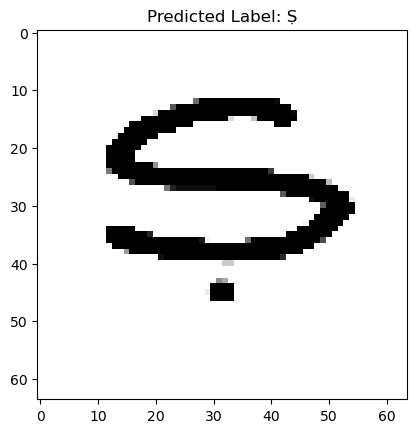

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread('C:/Users/OWNER/Machine Learning/FYP/img/img021_80.png')

# Process the image
img = cv2.resize(img, (64, 64))
img = img.astype('float32') / 255.0

# Expand the dimensions of the image
img = np.expand_dims(img, axis=0)

# Predict the probabilities for each class
prediction = model.predict(img)

# Get the label with the highest probability
predicted_label_index = np.argmax(prediction)
predicted_label_probability = prediction[0, predicted_label_index]

# Map label index to label name (replace label_mapping with your own mapping)
label_mapping = {0:'A', 1:'B', 2:'D', 3:'E', 4: 'F', 5:'G', 6:'GB', 7:'H', 8:'I', 9:'J', 10:'K', 
                 11:'L', 12:'M', 13:'N', 14:'O', 15:'P', 16:'R', 17: 'S', 18: 'T', 19: 'U', 20: 'W', 
                 21: 'Y', 22: 'a', 23: 'b', 24: 'd', 25:'e', 26:'f', 27:'g', 28:'gb', 29:'h', 30:'i', 
                 31: 'j', 32: 'k', 33: 'l', 34: 'm', 35: 'n', 36: 'o', 37: 'p', 38: 'r', 39: 's', 40: 't', 
                 41: 'u', 42: 'w', 43:'y', 44:'Ṣ', 45:'ṣ', 46:'Ẹ', 47:'ẹ', 48:'Ọ', 49:'ọ'}
predicted_label_name = label_mapping.get(predicted_label_index, 'Unknown')

# Print the predicted label and its probability
print(f'Predicted Label: {predicted_label_name} with probability: {predicted_label_probability:.2f}')

# Show the image
plt.imshow(img[0])  # Assuming img is a batch with a single image
plt.title(f'Predicted Label: {predicted_label_name}')
plt.show()

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 62, 62, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 31, 31, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 29, 29, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 29, 29, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,345,236 (5.13 MB)

 Trainable params: 1,345,234 (5.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)